# Fuji apple ripeness detection and 2D size estimation — minimal reproduction

Reproduction of **Zhu, Keyi et al., "Foundation model-based apple ripeness and size estimation for selective harvesting"** (arXiv:2502.01850v1; publisher version DOI 10.1016/j.compag.2025.110407), using the authors' released code and checkpoint.

**Scope (partial demonstration):** run the authors' `inference.py` pipeline on **one** Fuji RGB-D test image (`_MG_2657_24`, UdL collection):
1. Fine-tuned **Grounding-DINO** (author checkpoint `gdino_0.pth`, config `gdino_b_full.py`) detects apples with the text prompt `"ripe. unripe."` (score threshold 0.3).
2. **Segment Anything (SAM ViT-H)** generates a mask inside each detected box.
3. The authors' **2D-LSeg** size algorithm (`max_dist_mask`, outlier-removal 30–70 %, focal length 5805.34 px) estimates each apple's equatorial diameter in **mm**.
4. Overlay image + per-apple results table/CSV.

This is **one example**, not a reproduction of the paper's dataset-level metrics (Table 1 / Fig. 8).

日本語の概要: 論文の著者コードと公開チェックポイントを使い、富士りんごのRGB-D画像1枚について「熟し/未熟」検出（Grounding-DINO）、SAMによるマスク生成、2D-LSeg（max_dist_mask）による果実径(mm)推定を再現します。1事例の部分再現であり、論文のデータセット全体の精度評価の再現ではありません。

**Runtime: select a T4 GPU runtime (Runtime → Change runtime type → T4 GPU).** The pipeline uses SAM ViT-H (2.4 GB) and Grounding-DINO Swin-B; on CPU it was not validated and would be extremely slow.
**T4 GPUランタイムを選択してください。**

**Technical note:** Colab's default kernel is Python 3.13, for which no prebuilt `mmcv` wheel exists. The scientific pipeline therefore runs inside a pinned **Python 3.11 environment** created in this notebook with `uv`, using the authors' pinned stack (torch 2.1.1 + cu118, mmcv 2.1.0, mmdet 3.3.0). The notebook kernel only orchestrates, downloads, and displays. すべての解析はノートブック内で作成したPython 3.11環境で実行されます。

## 1. Pinned Python 3.11 environment

Create an isolated Python 3.11 environment with `uv` (a fast, self-contained installer) directly under `/content`, and install the authors' scientific stack into it: torch 2.1.1 + cu118 (T4-compatible) from the official PyTorch index, the **mmcv 2.1.0 prebuilt wheel** for cu118/torch2.1 from OpenMMLab's official index (the version pinned by the authors' README), **mmdet 3.3.0** (the release containing Grounding DINO), and Segment Anything. This takes several minutes and downloads ≈4 GB.

日本語: Colab既定のPython 3.13にはmmcvのビルド済みwheelがないため、`uv`でPython 3.11環境を /content に作成し、著者指定のスタック（torch 2.1.1+cu118、mmcv 2.1.0、mmdet 3.3.0、Segment Anything）をインストールします（数分、約4GB）。

In [ ]:
%pip install -q uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 20.6/20.6 MB 239.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 95.0 MB/s eta 0:00:00


Create the environment and install the pinned packages into it (output is streamed so failures are visible). `uv` fetches its own CPython 3.11; the wheels come from the official PyTorch cu118 index and OpenMMLab's official cu118/torch2.1 wheel index.

日本語: 環境を作成し、公式インデックスからピン留めしたパッケージをインストールします（出力はストリーミング表示）。

In [ ]:
import subprocess, sys

LOG = "/content/env_setup.log"

def run(cmd):
    print("+", " ".join(cmd), flush=True)
    with open(LOG, "wb") as fh:
        r = subprocess.run(cmd, stdout=fh, stderr=subprocess.STDOUT)
    if r.returncode != 0:
        print(open(LOG).read()[-2500:], flush=True)
        raise RuntimeError(f"command failed with exit code {r.returncode}")

run([sys.executable, "-m", "uv", "venv", "--clear", "--python", "3.11", "/content/fujienv"])
PY = "/content/fujienv/bin/python"
run([sys.executable, "-m", "uv", "pip", "install", "--python", PY,
     "numpy==1.26.4", "torch==2.1.1+cu118", "torchvision==0.16.1+cu118",
     "--index-url", "https://download.pytorch.org/whl/cu118"])
run([sys.executable, "-m", "uv", "pip", "install", "--python", PY,
     "mmengine", "mmcv==2.1.0", "numpy==1.26.4",
     "--find-links", "https://download.openmmlab.com/mmcv/dist/cu118/torch2.1/index.html"])
run([sys.executable, "-m", "uv", "pip", "install", "--python", PY,
     "mmdet==3.3.0", "fairscale", "transformers==4.36.2", "segment-anything",
     "opencv-python-headless",
     "scipy", "matplotlib", "numpy==1.26.4"])
print("environment ready:", PY)

+ /usr/bin/python3 -m uv venv --clear --python 3.11 /content/fujienv


+ /usr/bin/python3 -m uv pip install --python /content/fujienv/bin/python numpy==1.26.4 torch==2.1.1+cu118 torchvision==0.16.1+cu118 --index-url https://download.pytorch.org/whl/cu118


+ /usr/bin/python3 -m uv pip install --python /content/fujienv/bin/python mmengine mmcv==2.1.0 numpy==1.26.4 --find-links https://download.openmmlab.com/mmcv/dist/cu118/torch2.1/index.html


+ /usr/bin/python3 -m uv pip install --python /content/fujienv/bin/python mmdet==3.3.0 fairscale transformers==4.36.2 segment-anything opencv-python-headless scipy matplotlib numpy==1.26.4


environment ready: /content/fujienv/bin/python


## 2. Author code from the pinned revision

Fetch the authors' sizing/mask/plot utilities from the GitHub repository at the exact verified commit `a0b71062800490d62165d0c6e41c0afd933943d9` (raw URLs, no clone). Each file is verified against its **git blob SHA-1** before use, so the executed code is byte-identical to the pinned revision.

日本語: 著者コードをピン留めしたコミットa0b7106からraw取得し、git blob SHA-1で完全性を検証します。

In [ ]:
import hashlib, urllib.request, pathlib

REPO = "https://raw.githubusercontent.com/zhukeyi-stan/Fuji_Ripeness_And_Size_Estimation"
COMMIT = "a0b71062800490d62165d0c6e41c0afd933943d9"
FILES = {  # path -> git blob sha1 at the pinned commit
    "utils/sizing_algorithms.py": "a04061f174cfeb7f5b7735b491bf348d2b7332f5",
    "utils/pcloud_operation.py":  "75641088106b2b453f4ffde39c741c825e4fd4fa",
    "utils/plot.py":              "7b131a2cf39f673783d75cf369bca03dc3a2c3cc",
    "inference.py":               "cc89a56b14f82c86e8ccc11f6a86a5303161498b",
}
base = pathlib.Path("/content/Fuji_Ripeness")
for rel, blob in FILES.items():
    dest = base / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    data = urllib.request.urlopen(f"{REPO}/{COMMIT}/{rel}", timeout=120).read()
    digest = hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()
    assert digest == blob, f"blob mismatch for {rel}: {digest}"
    dest.write_bytes(data)
    print(f"verified {rel}: {len(data)} bytes, blob {digest[:12]}")

verified utils/sizing_algorithms.py: 10470 bytes, blob a04061f174cf


verified utils/pcloud_operation.py: 1845 bytes, blob 75641088106b


verified utils/plot.py: 2356 bytes, blob 7b131a2cf39f


verified inference.py: 4453 bytes, blob cc89a56b14f8


## 3. Data and weights (all downloads stay on the Colab VM)

Download from the authors' Kaggle dataset `zhukeyi1/fuji-ripeness-and-size-dataset` (GPL-3) **only the four files needed** for this one-image demonstration, via `kagglehub` partial download (public dataset, no credentials): the sample RGB image and its depth array, plus the fine-tuned Grounding-DINO config and checkpoint (937 MB). Files are copied under `/content/data` for stable paths. Then fetch the official SAM ViT-H checkpoint from Facebook AI and verify its byte size (2,564,550,879 B).

日本語: Kaggleデータセット（GPL-3）から必要な4ファイルのみkagglehubで部分取得し /content/data へ配置、SAM ViT-H公式チェックポイントをFacebook AIから取得してサイズ検証します。合計約3.4GB。

In [ ]:
import os, shutil
os.environ["KAGGLEHUB_CACHE"] = "/content/kagglehub"
import kagglehub

KH = "zhukeyi1/fuji-ripeness-and-size-dataset"
NEEDED = ["test/images/_MG_2657_24.png", "test/depths/_MG_2657_24.npy",
          "gdino/gdino_b_full.py", "gdino/gdino_0.pth"]
paths = {}
for rel in NEEDED:
    p = kagglehub.dataset_download(KH, path=rel)
    dest = "/content/data/" + rel
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    shutil.copy(p, dest)
    paths[rel] = dest
    print(rel, "->", dest, os.path.getsize(dest), "bytes")
import json
json.dump({rel: paths[rel] for rel in NEEDED}, open("/content/paths.json", "w"), indent=1)

  0%|          | 0.00/1.59M [00:00<?, ?B/s]

 63%|██████▎   | 1.00M/1.59M [00:01<00:00, 758kB/s]

100%|██████████| 1.59M/1.59M [00:01<00:00, 1.18MB/s]

100%|██████████| 1.59M/1.59M [00:01<00:00, 1.07MB/s]

test/images/_MG_2657_24.png -> /content/data/test/images/_MG_2657_24.png 1668437 bytes


...

 99%|█████████▉| 884M/894M [01:00<00:00, 16.1MB/s]

 99%|█████████▉| 888M/894M [01:00<00:00, 16.5MB/s]

100%|█████████▉| 892M/894M [01:01<00:00, 16.9MB/s]

100%|██████████| 894M/894M [01:01<00:00, 15.3MB/s]

gdino/gdino_0.pth -> /content/data/gdino/gdino_0.pth 937421221 bytes


Official SAM ViT-H checkpoint (the author README says to use the official Segment Anything checkpoint; `inference.py` pins `vit_h` / `sam_vit_h_4b8939.pth`).

日本語: 公式SAM ViT-Hチェックポイントを取得し、バイト数を検証します。

In [ ]:
import urllib.request, pathlib

SAM_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
SAM_EXPECTED = 2564550879  # bytes, official sam_vit_h_4b8939.pth (verified 2026-10-05)
sam_path = pathlib.Path("/content/sam_vit_h_4b8939.pth")
if not sam_path.exists() or sam_path.stat().st_size != SAM_EXPECTED:
    tmp = sam_path.with_suffix(".part")
    urllib.request.urlretrieve(SAM_URL, tmp)
    tmp.rename(sam_path)
assert sam_path.stat().st_size == SAM_EXPECTED, sam_path.stat().st_size
print("SAM checkpoint OK:", sam_path, sam_path.stat().st_size, "bytes")

SAM checkpoint OK: /content/sam_vit_h_4b8939.pth 2564550879 bytes


## 4. Input preview (before any analysis)

Show the actual sample before running the models: the RGB image `_MG_2657_24.png` (UdL collection) and its aligned depth array `_MG_2657_24.npy` (float64, metres) as a heatmap. Dimensions are printed from the actual data.

日本語: 解析前に実入力を確認します。RGB画像と整列済み深度（メートル単位、float64）のヒートマップを表示し、実寸法を出力します。

image: (1300, 1300, 3) uint8 | depth: (1300, 1300) float64
depth valid range: 2.47–4.09 m (median 3.04)


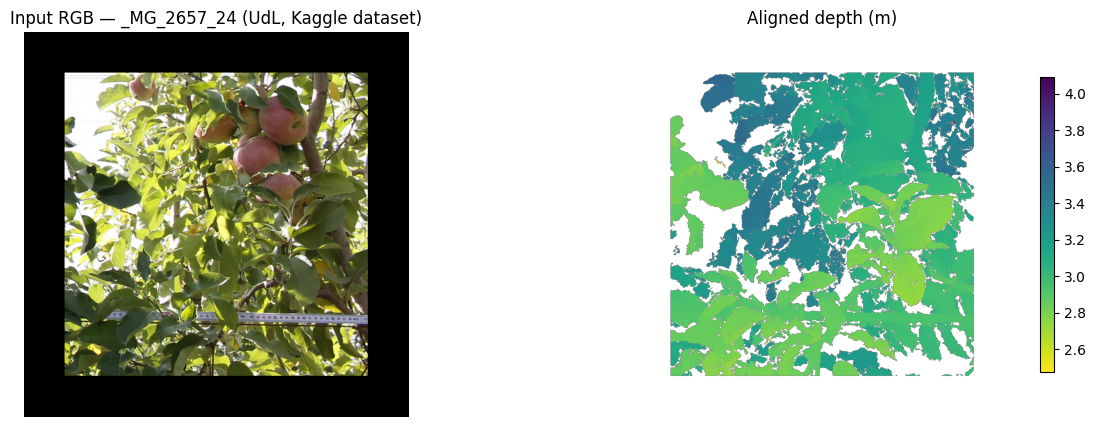

In [ ]:
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread(paths["test/images/_MG_2657_24.png"])          # BGR, uint8
depth = np.load(paths["test/depths/_MG_2657_24.npy"])            # metres
print("image:", img.shape, img.dtype, "| depth:", depth.shape, depth.dtype)
valid = depth[(depth > 0.2) & (depth < 6)]
print(f"depth valid range: {valid.min():.2f}–{valid.max():.2f} m (median {np.median(valid):.2f})")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax[0].set_title("Input RGB — _MG_2657_24 (UdL, Kaggle dataset)"); ax[0].axis("off")
h = ax[1].imshow(np.where((depth > 0.2) & (depth < 6), depth, np.nan), cmap="viridis_r")
ax[1].set_title("Aligned depth (m)"); ax[1].axis("off")
plt.colorbar(h, ax=ax[1], fraction=0.03)
plt.show()

## 5. The inference pipeline (authors' code, adapted paths only)

The cell below writes `/content/run_inference.py`. It is the authors' `inference.py` main flow with **only** these documented changes: (a) paths under `/content` read from `paths.json`; (b) device auto-detected (`cuda:0` on the T4); (c) results written to `/content/inference_results.png` (authors' `save_fig` from `utils/plot.py`) and `/content/apple_sizes.csv` instead of a fixed file. `detect` and `segment` are copied verbatim from `inference.py:20–43`; sizing uses the authors' default `max_dist_mask` (paper's 2D-LSeg) with outlier-removal 30–70 % and focal length 5805.34 px (UdL, `inference.py:74`). Label convention: **0 = ripe (red box), 1 = unripe (green box)**.

日本語: 次のセルは著者の `inference.py` の本体を、パス・デバイス検出・出力先のみ変更して書き出します。detect/segmentは著者コードの完全コピー、サイズ推定は著者既定のmax_dist_mask（2D-LSeg）、外れ値除去30–70%、焦点距離5805.34px（UdL）です。0=熟果（赤枠）、1=未熟果（緑枠）。

In [ ]:
PIPELINE = r'''
import json, sys, time, csv
sys.path.insert(0, "/content/Fuji_Ripeness")
import numpy as np, cv2, torch
from mmdet.apis import init_detector, inference_detector
from segment_anything import sam_model_registry, SamPredictor
from utils.sizing_algorithms import size_estimation
from utils.plot import save_fig

P = json.load(open("/content/paths.json"))
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
if DEVICE == "cpu":
    print("WARNING: no GPU visible; CPU was not validated and is extremely slow.")
print("device:", DEVICE, "| torch", torch.__version__)

FOCAL_LENGTH = 5805.34      # UdL images (inference.py:74)
REMOVAL_RATE = (30, 70)     # inference.py defaults
ALGORITHM = "max_dist_mask" # inference.py default = paper 2D-LSeg

def detect(detector, img, score_thres=0.3):          # verbatim inference.py:20-30
    t0 = time.time()
    res = inference_detector(detector, img, text_prompt="ripe. unripe.", custom_entities=True)
    pred_bboxes = res.pred_instances.bboxes[res.pred_instances.scores > score_thres, :]
    pred_labels = res.pred_instances.labels[res.pred_instances.scores > score_thres]
    pred_scores = res.pred_instances.scores[res.pred_instances.scores > score_thres]
    return pred_bboxes.cpu(), pred_labels.cpu(), pred_scores.cpu(), time.time() - t0

def segment(segmentor, img, pred_bboxes):            # verbatim inference.py:32-43
    t0 = time.time()
    transformed_bboxes = segmentor.transform.apply_boxes_torch(pred_bboxes, img.shape[:2]).to(DEVICE)
    segmentor.set_image(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    masks, _, _ = segmentor.predict_torch(
        point_coords=None, point_labels=None,
        boxes=transformed_bboxes, multimask_output=False,
    )
    return masks, time.time() - t0

detector = init_detector(P["gdino/gdino_b_full.py"], P["gdino/gdino_0.pth"], device=DEVICE)
segmentor = SamPredictor(sam_model_registry["vit_h"](checkpoint="/content/sam_vit_h_4b8939.pth").to(DEVICE))

img = cv2.imread(P["test/images/_MG_2657_24.png"])
depth = np.load(P["test/depths/_MG_2657_24.npy"])
pred_bboxes, pred_labels, pred_scores, det_time = detect(detector, img)
print(f"detections: {len(pred_bboxes)} (ripe {int((pred_labels==0).sum())}, unripe {int((pred_labels==1).sum())}) in {det_time:.2f} s")
for i, (b, l, s) in enumerate(zip(pred_bboxes, pred_labels, pred_scores)):
    print(f"  [{i}] {'ripe' if l==0 else 'unripe'} score={s:.2f} bbox=[{b[0]:.0f},{b[1]:.0f},{b[2]:.0f},{b[3]:.0f}]")

if pred_bboxes.shape[0] == 0:
    raise SystemExit("No detections — nothing to size.")
masks, seg_time = segment(segmentor, img, pred_bboxes)
print(f"{masks.shape[0]} masks in {seg_time:.2f} s")

rows, diameters = [], []
for i in range(pred_bboxes.shape[0]):
    bbox = pred_bboxes[i].numpy()
    mask = masks[i, 0].cpu().numpy()
    d = size_estimation(ALGORITHM, (depth, mask, bbox, FOCAL_LENGTH, REMOVAL_RATE))
    diameters.append(d)
    rows.append({"apple": i, "label": "ripe" if pred_labels[i] == 0 else "unripe",
                 "score": round(float(pred_scores[i]), 3),
                 "diameter_mm": None if d < 0 else round(float(d), 2)})
with open("/content/apple_sizes.csv", "w", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=["apple", "label", "score", "diameter_mm"])
    w.writeheader(); w.writerows(rows)
for r in rows:
    print(r)
save_fig(cv2.cvtColor(img, cv2.COLOR_RGB2BGR), pred_bboxes, masks, pred_labels,
         "/content/inference_results.png", diameters)
print("saved /content/inference_results.png and /content/apple_sizes.csv")
'''
open("/content/run_inference.py", "w").write(PIPELINE)
print("pipeline script written:", len(PIPELINE), "chars")

pipeline script written: 3525 chars


## 6. Run the pipeline in the pinned environment

Execute the script with the Python 3.11 environment's interpreter. Detection and mask counts, per-apple ripeness/score/bbox, and 2D-LSeg diameters (mm) are printed here; this is the actual scientific execution.

日本語: ピン留めしたPython 3.11環境のインタプリタでパイプラインを実行します。検出数・クラス・スコア・2D-LSegによる果実径(mm)が出力されます。

In [ ]:
import subprocess
PIPE_LOG = "/content/pipeline.log"
with open(PIPE_LOG, "wb") as fh:
    import os
    env = dict(os.environ, MPLBACKEND="Agg")
    r = subprocess.run(["/content/fujienv/bin/python", "/content/run_inference.py"],
                       stdout=fh, stderr=subprocess.STDOUT, env=env)
print(open(PIPE_LOG).read()[-4000:], flush=True)
if r.returncode != 0:
    raise RuntimeError(f"pipeline failed with exit code {r.returncode}")

/content/fujienv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/content/fujienv/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/content/fujienv/lib/python3.11/site-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
device: cuda:0 | torch 2.1.1+cu118
Loads checkpoint by local backend from path: /content/data/gdino/gdino_0.pth
detections: 8 (ripe 5, unripe 3) in 3.01 s
  [0] ripe score=0.76 bbox=[708,356,86

## 7. Results table and annotated overlay

Load the CSV written by the pipeline and display the overlay produced by the authors' `save_fig` (SAM masks overlaid; red boxes = ripe, green boxes = unripe; blue text = 2D-LSeg diameter in mm, clipped to 40–100 mm by the author code, `sizing_algorithms.py:31`).

日本語: パイプラインが出力したCSVと、著者のsave_figによる注釈付き画像（SAMマスク重ね合わせ、熟果=赤枠、未熟果=緑枠、青文字=推定直径mm）を表示します。

 apple  label  score  diameter_mm
     0   ripe  0.756        85.13
     1   ripe  0.751        95.21
     2   ripe  0.707        82.62
     3   ripe  0.528        82.72
     4   ripe  0.441        53.14
     5 unripe  0.378        53.14
     6 unripe  0.367        56.18
     7 unripe  0.306        94.89

2D-LSeg diameter (mm): mean 75.4, range 53.1–95.2 (n=8)


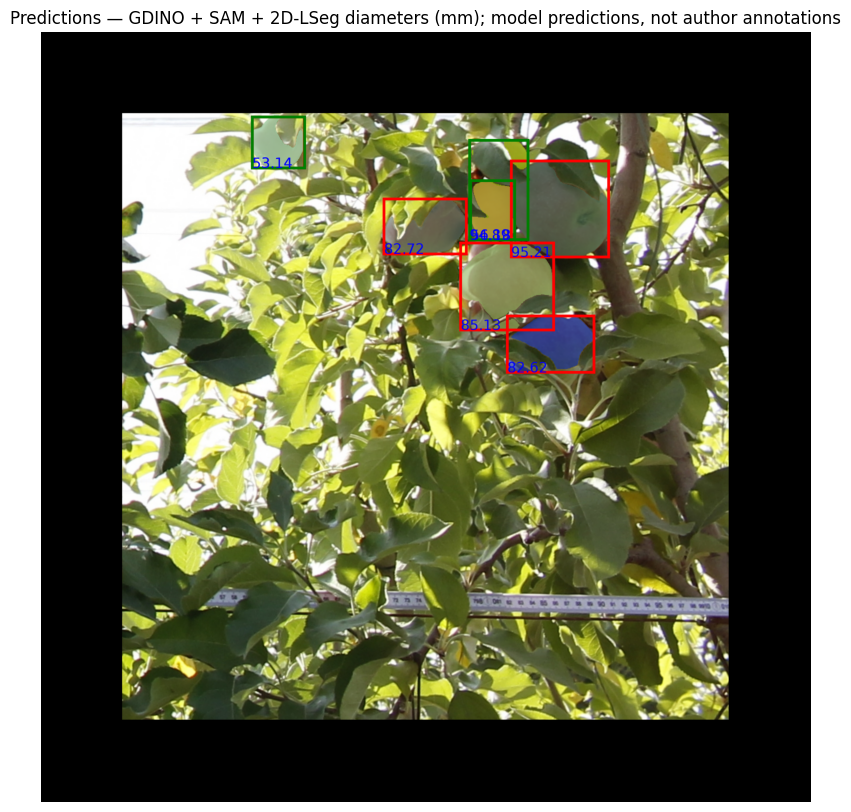

In [ ]:
import pandas as pd, matplotlib.pyplot as plt, cv2

df = pd.read_csv("/content/apple_sizes.csv")
print(df.to_string(index=False))
ok = df.diameter_mm.dropna()
if len(ok):
    print(f"\n2D-LSeg diameter (mm): mean {ok.mean():.1f}, range {ok.min():.1f}–{ok.max():.1f} (n={len(ok)})")

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(cv2.imread("/content/inference_results.png"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Predictions — GDINO + SAM + 2D-LSeg diameters (mm); model predictions, not author annotations")
plt.show()

## 8. Interpretation and limitations

**What this run shows.** On the authors' own default example (`_MG_2657_24`, UdL), the released fine-tuned Grounding-DINO detects ripe/unripe apples with the prompt `"ripe. unripe."`, SAM ViT-H segments each box, and the 2D-LSeg (`max_dist_mask`) algorithm returns equatorial diameters in millimetres (clipped to 40–100 mm by the author code, `sizing_algorithms.py:31`). Per the paper (§3.2), 2D-LSeg had the smallest median error of the six algorithms when using ground-truth boxes; here we use *detected* boxes, which the paper reports changes results only marginally (§3.3).

**Limitations.**
- Single example; no claim about Table 1 mAP/mAR or dataset-level size error.
- Ripeness labels in the dataset are heuristic (redness + capture date), as the paper's flow notes.
- The fine-tuned checkpoint and config come from the authors' Kaggle dataset (GPL-3); the repo itself carries no LICENSE — reuse terms rest on the dataset license.
- Diameters were not compared to caliper ground truth here (the author `inference.py` does not use a per-apple GT file either).
- The pipeline runs in a pinned Python 3.11 environment (torch 2.1.1+cu118 / mmcv 2.1.0 / mmdet 3.3.0) because Colab's default Python 3.13 has no mmcv wheel; author functions are byte-identical to commit `a0b7106`.

References: paper (arXiv:2502.01850v1 / DOI 10.1016/j.compag.2025.110407); code github.com/zhukeyi-stan/Fuji_Ripeness_And_Size_Estimation @ a0b7106; Kaggle dataset zhukeyi1/fuji-ripeness-and-size-dataset; SAM (facebookresearch/segment-anything).

日本語: 本例は1事例の部分再現です。熟度ラベルは発見的ラベルであり、ここではキャリパー実測値との比較は行っていません（著者のinference.pyも同様）。パイプラインはPython 3.11固定環境（torch 2.1.1+cu118 / mmcv 2.1.0 / mmdet 3.3.0）で動作します。